In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('4-Algerian_forest_fires_dataset.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [5]:
df.isna().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [6]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [7]:
df.dropna(axis = 0 , inplace = True)

In [8]:
df.drop(index = 124 , inplace = True)

In [9]:
df.reset_index(inplace = True)

In [10]:
df.loc[:121 , 'Region'] = 0
df.loc[121: , 'Region'] = 1

In [11]:
df[110 : 130]

,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
110,110,19,9,2012,29,57,14,0,89.3,12.5,41.3,7.8,14.2,9.7,fire,0.0
111,111,20,9,2012,28,84,18,0,83.8,13.5,49.3,4.5,16,6.3,fire,0.0
112,112,21,9,2012,31,55,11,0,87.8,16.5,57.9,5.4,19.2,8.3,fire,0.0
113,113,22,9,2012,31,50,19,0.6,77.8,10.6,41.4,2.4,12.9,2.8,not fire,0.0
114,114,23,9,2012,32,54,11,0.5,73.7,7.9,30.4,1.2,9.6,0.7,not fire,0.0
115,115,24,9,2012,29,65,19,0.6,68.3,5.5,15.2,1.5,5.8,0.7,not fire,0.0
116,116,25,9,2012,26,81,21,5.8,48.6,3,7.7,0.4,3,0.1,not fire,0.0
117,117,26,9,2012,31,54,11,0,82,6,16.3,2.5,6.2,1.7,not fire,0.0
118,118,27,9,2012,31,66,11,0,85.7,8.3,24.9,4,9,4.1,fire,0.0
119,119,28,9,2012,32,47,14,0.7,77.5,7.1,8.8,1.8,6.8,0.9,not fire,0.0


In [12]:
df.drop(columns = 'index' , inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    object 
 1   month        243 non-null    object 
 2   year         243 non-null    object 
 3   Temperature  243 non-null    object 
 4    RH          243 non-null    object 
 5    Ws          243 non-null    object 
 6   Rain         243 non-null    object 
 7   FFMC         243 non-null    object 
 8   DMC          243 non-null    object 
 9   DC           243 non-null    object 
 10  ISI          243 non-null    object 
 11  BUI          243 non-null    object 
 12  FWI          243 non-null    object 
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(1), object(14)
memory usage: 28.6+ KB


In [13]:
df.columns 

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [14]:
df.columns = df.columns.str.strip(' ') #Boşluk karakterleri siler
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [15]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [16]:
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

In [17]:
df[['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']] = df[['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']].astype(float)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(8), int64(6), object(1)
memory usage: 28.6+ KB


In [19]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.502058
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,1.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [20]:
df['Classes'].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'not fire     ', 'not fire    '], dtype=object)

In [21]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0 , 1)

In [22]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

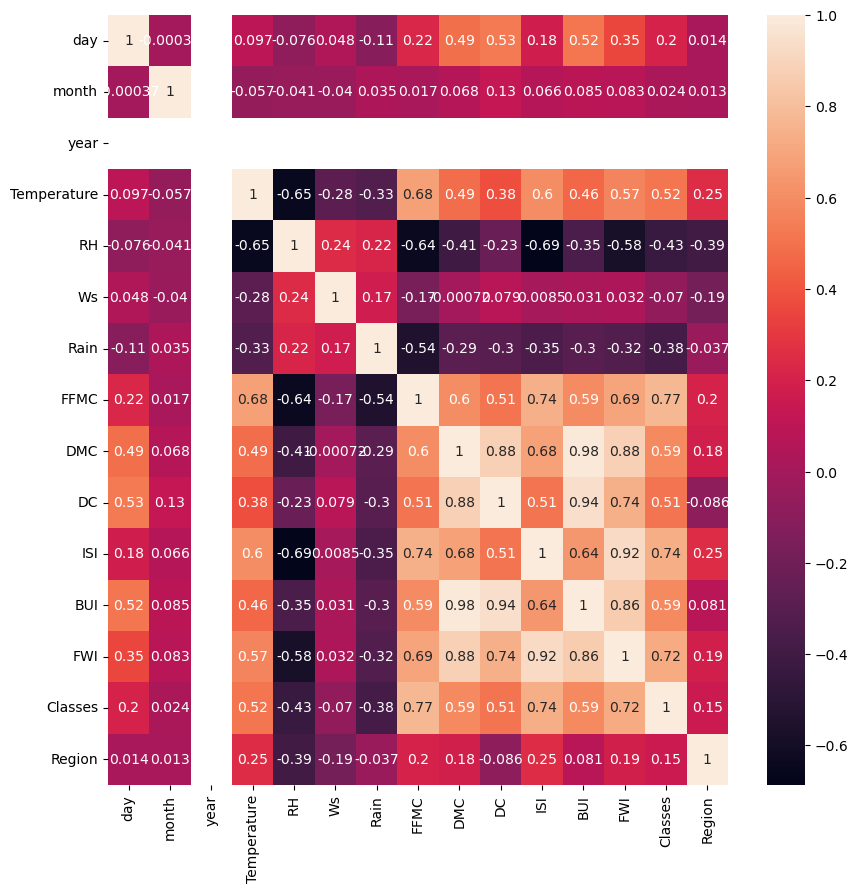

In [23]:
fig = plt.figure(figsize = (10,10))
sns.heatmap(df.corr() , annot = True)
plt.show()

In [24]:
df.drop(['day' , 'month' , 'year'] , inplace = True , axis = 1)

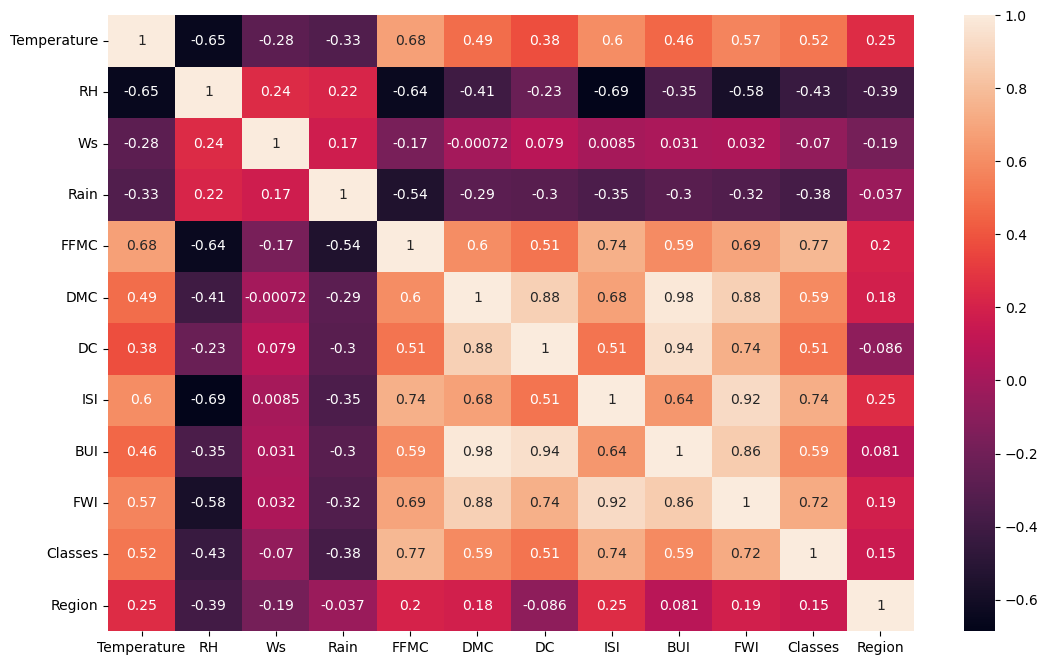

In [25]:
fig = plt.figure(figsize = (13,8))
sns.heatmap(df.corr() , annot = True)
plt.show()

In [26]:
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.253296
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.393805
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.185542
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.037390
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.203364
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.183583
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.085989
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.254179
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.081125
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.189415


In [27]:
from sklearn.model_selection import train_test_split 

In [28]:
# x - y ayır 
# train test ayır 
# correlation fazla olan columns bul kaldır 
# modeli eğit

In [29]:
X = df.drop(columns = 'FWI' , axis = 1)
y = df['FWI']

In [30]:
X_train , X_test , y_train ,y_test = train_test_split(X , y , random_state = 15 , test_size = 0.25)

In [31]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.644824,-0.322405,-0.222809,0.600615,0.483815,0.362859,0.579809,0.452819,0.463959,0.229479
RH,-0.644824,1.000000,0.205669,0.171031,-0.643767,-0.395535,-0.204568,-0.682107,-0.337032,-0.427947,-0.368402
Ws,-0.322405,0.205669,1.000000,0.152948,-0.135584,0.011874,0.104577,0.021616,0.051452,-0.044791,-0.181246
Rain,-0.222809,0.171031,0.152948,1.000000,-0.475600,-0.263007,-0.282983,-0.325552,-0.276457,-0.363013,0.049735
FFMC,0.600615,-0.643767,-0.135584,-0.475600,1.000000,0.592446,0.483610,0.732549,0.577031,0.770641,0.158505
DMC,0.483815,-0.395535,0.011874,-0.263007,0.592446,1.000000,0.871387,0.658793,0.980646,0.549624,0.153781
DC,0.362859,-0.204568,0.104577,-0.282983,0.483610,0.871387,1.000000,0.467977,0.939248,0.468011,-0.120874
ISI,0.579809,-0.682107,0.021616,-0.325552,0.732549,0.658793,0.467977,1.000000,0.617313,0.714801,0.241664
BUI,0.452819,-0.337032,0.051452,-0.276457,0.577031,0.980646,0.939248,0.617313,1.000000,0.550431,0.044453
Classes,0.463959,-0.427947,-0.044791,-0.363013,0.770641,0.549624,0.468011,0.714801,0.550431,1.000000,0.136752


In [32]:
def corelation_for_dropping(df , treshold) : 
    corr = df.corr()
    columns_to_drop = set()
    for i in range(len(corr.columns)) : 
        for j in range(i) : 
            if abs(corr.iloc[i , j]) > treshold : 
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [33]:
dropped_columns = corelation_for_dropping(X_train , 0.85)
dropped_columns

{'BUI', 'DC'}

In [34]:
X_train.drop(dropped_columns , inplace = True , axis = 1)
X_test.drop(dropped_columns , inplace = True , axis = 1)
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
55,36,53,19,0.0,89.2,17.1,10.0,1,0.0
6,33,54,13,0.0,88.2,9.9,6.4,1,0.0
137,29,87,15,0.4,47.4,4.2,0.2,0,1.0
122,32,71,12,0.7,57.1,2.5,0.6,0,1.0
40,33,76,14,0.0,81.1,8.1,2.6,0,0.0
...,...,...,...,...,...,...,...,...,...
128,35,44,17,0.2,85.6,9.9,5.4,1,1.0
119,32,47,14,0.7,77.5,7.1,1.8,0,0.0
133,27,58,17,0.0,88.9,21.3,8.7,1,1.0
140,32,67,14,4.5,64.6,4.4,1.0,0,1.0


In [35]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

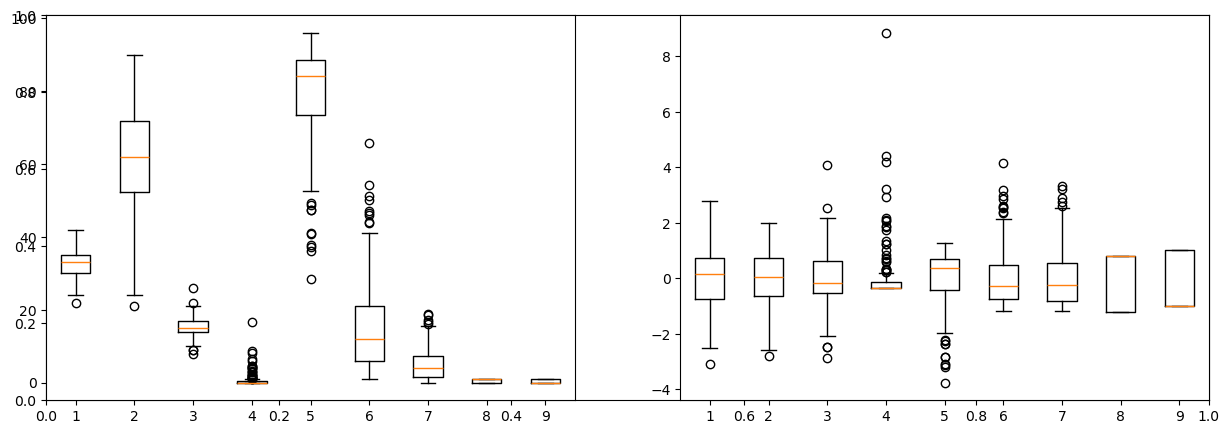

In [36]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
plt.boxplot(X_train)
plt.subplot(1,2,2)
plt.boxplot(X_train_scaled)
plt.show()

# SCALE EDILMEDEN ONCEKI HALI VE SCALE EDILDIKTEN SORNAKI HALI 

In [37]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [38]:
regression.fit(X_train_scaled , y_train)

LinearRegression()

In [39]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [40]:
y_pred = regression.predict(X_test_scaled)

In [41]:
mae = mean_absolute_error(y_test , y_pred) 
mse = mean_squared_error(y_test , y_pred) 
r2 = r2_score(y_test , y_pred) 

print('Mean Absolute Error : ', mae)
print('Mean Squared Error : ', mse)
print('R2 Score : ' , r2)
# %98 başarı oranı 

Mean Absolute Error :  0.7171138184801005
Mean Squared Error :  0.8917537607454493
R2 Score :  0.9835907018453582


In [42]:
# Farklı yontemler deneyelim

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

regression = Ridge()
regression.fit(X_train_scaled , y_train)

y_pred = regression.predict(X_test_scaled)

mae = mean_absolute_error(y_test , y_pred) 
mse = mean_squared_error(y_test , y_pred) 
r2 = r2_score(y_test , y_pred) 

print('Mean Absolute Error : ', mae)
print('Mean Squared Error : ', mse)
print('R2 Score : ' , r2)
# %98 başarı

Mean Absolute Error :  0.7225880685738713
Mean Squared Error :  0.9037507938268072
R2 Score :  0.9833699425937925


In [44]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

regression = Lasso()
regression.fit(X_train_scaled , y_train)

y_pred = regression.predict(X_test_scaled)

mae = mean_absolute_error(y_test , y_pred) 
mse = mean_squared_error(y_test , y_pred) 
r2 = r2_score(y_test , y_pred) 

print('Mean Absolute Error : ', mae)
print('Mean Squared Error : ', mse)
print('R2 Score : ' , r2)
#% 95 başarı

Mean Absolute Error :  1.216272633800629
Mean Squared Error :  2.6029377368132187
R2 Score :  0.9521029422229386


In [45]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

regression = ElasticNet()
regression.fit(X_train_scaled , y_train)

y_pred = regression.predict(X_test_scaled)

mae = mean_absolute_error(y_test , y_pred) 
mse = mean_squared_error(y_test , y_pred) 
r2 = r2_score(y_test , y_pred) 

print('Mean Absolute Error : ', mae)
print('Mean Squared Error : ', mse)
print('R2 Score : ' , r2)
# %89 başarı

Mean Absolute Error :  1.7493286471090155
Mean Squared Error :  5.569160502382823
R2 Score :  0.8975210207375393


In [46]:
# Ridge Lasso ve Elastic Net ' de bulunan ceza parametre değerlerini değiştirerek model doğruluk oranlarını arttırabiliriz

In [47]:
# Bunun icin lambda veya ceza parametrelerin değiştireceğiz cross validation(çapraz doğrulama) işlemi ile
# Ancak formulde bulunan lambda değişkeni kodlamada alpha ile isimlendirilir birebir aynı şeylerdir 

In [48]:
# --------------- Cross Vlaidation 

In [49]:
from sklearn.linear_model import LassoCV

In [50]:
lassocv = LassoCV(cv = 5)
lassocv.fit(X_train_scaled , y_train)

y_pred = lassocv.predict(X_test_scaled)

mae = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print('Mean Absolute Error : ', mae)
print('Mean Squared Error : ', mse)
print('R2 Score : ' , r2)

# Yukaridaki sadece lasso ile yapığımız eğitimde r2 score = 95 iken burada %98 doğruluk oranına ulaştık
# Cünkü cv yani cross validation degerini biz verdik ve 
# algoritma tek tek deneyerek en uygun alpha degerini bulup bu doğrultuda işlem yaptı
# Yukardaki lasso işleminde alpha default olarak 1 alınıyordu burada model deneyerek en uygun degeri buldu

Mean Absolute Error :  0.7339171129265367
Mean Squared Error :  5.569160502382823
R2 Score :  0.9831353037814284


In [51]:
lassocv.alphas_ # Algoritmanın tek tek en uygun degeri bulmak icin denediği alpha degerleri

array([6.79691292, 6.33882374, 5.91160823, 5.51318562, 5.14161537,
       4.7950877 , 4.47191484, 4.17052274, 3.88944347, 3.627308  ,
       3.38283958, 3.15484751, 2.94222135, 2.74392548, 2.55899408,
       2.38652645, 2.22568255, 2.075679  , 1.93578518, 1.80531974,
       1.68364723, 1.57017504, 1.4643505 , 1.36565818, 1.27361739,
       1.18777984, 1.10772745, 1.03307033, 0.96344485, 0.89851189,
       0.83795519, 0.78147982, 0.72881069, 0.67969129, 0.63388237,
       0.59116082, 0.55131856, 0.51416154, 0.47950877, 0.44719148,
       0.41705227, 0.38894435, 0.3627308 , 0.33828396, 0.31548475,
       0.29422213, 0.27439255, 0.25589941, 0.23865264, 0.22256826,
       0.2075679 , 0.19357852, 0.18053197, 0.16836472, 0.1570175 ,
       0.14643505, 0.13656582, 0.12736174, 0.11877798, 0.11077275,
       0.10330703, 0.09634448, 0.08985119, 0.08379552, 0.07814798,
       0.07288107, 0.06796913, 0.06338824, 0.05911608, 0.05513186,
       0.05141615, 0.04795088, 0.04471915, 0.04170523, 0.03889

In [52]:
print(lassocv.alpha_) # Algoritmanın bulup kullandıgı en uygun alpha

0.031548475118595085


In [53]:
# Elastic Net 

In [54]:
from sklearn.linear_model import ElasticNetCV
elasticnet = ElasticNetCV(cv = 5)
elasticnet.fit(X_train_scaled , y_train)

y_pred = elasticnet.predict(X_test_scaled)

mae = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print('Mean Absolute Error : ', mae)
print('Mean Squared Error : ', mse)
print('R2 Score : ' , r2)


# Alpha = 1 olan halinde r2_score = 89 idi 

Mean Absolute Error :  0.747574406417884
Mean Squared Error :  5.569160502382823
R2 Score :  0.9826166026645415
